In [4]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

In [5]:
ckpt_files = glob.glob(f"./hww_pcres_regressor/logs/version_0/checkpoints/*")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Using checkpoint: ./hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=73-val_loss=11.73.ckpt


In [6]:
dm = train.main(train=False) # Retrieve datamodule used in training
model = LightningWBoson.load_from_checkpoint(ckpt_path) # Load model from checkpoint
model.eval()

# Get the test dataloader
dm.setup(stage="test")
test_loader = dm.test_dataloader()

# Run inference
predictions = np.empty([0, dm.X.shape[1]-2]) # Without including W0 and W1 mass
true_labels = np.empty([0, dm.Y.shape[1]])
train_features = np.empty([0, dm.X.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for batch in test_loader:
        inputs, targets = batch
        inputs = inputs.to(device)
        targets = targets.to(device)
    
        outputs = model(inputs)
        
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...
Training objects shape: (2963488, 10)
(2963488, 16)
Lepton in W rest frame shapes: (2963488, 4) (2963488, 4)
Target objects shape: (2963488, 10)
Loading model from checkpoint for evaluation... return datamodule


FileNotFoundError: [Errno 2] No such file or directory: '/root/work/hww_pcres_regressor/hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=73-val_loss=11.73.ckpt'

In [ ]:
pred_lep_pos_px = predictions[..., 0]
pred_lep_pos_py = predictions[..., 1]
pred_lep_pos_pz = predictions[..., 2]
pred_lep_pos_energy = predictions[..., 3]
pred_lep_neg_px = predictions[..., 4]
pred_lep_neg_py = predictions[..., 5]
pred_lep_neg_pz = predictions[..., 6]
pred_lep_neg_energy = predictions[..., 7]
pred_w0_mass = predictions[..., 8]
pred_w1_mass = predictions[..., 9]

true_lep_pos_px = true_labels[..., 0]
true_lep_pos_py = true_labels[..., 1]
true_lep_pos_pz = true_labels[..., 2]
true_lep_pos_energy = true_labels[..., 3]
true_lep_neg_px = true_labels[..., 4]
true_lep_neg_py = true_labels[..., 5]
true_lep_neg_pz = true_labels[..., 6]
true_lep_neg_energy = true_labels[..., 7]
true_w0_mass = true_labels[..., 8]
true_w1_mass = true_labels[..., 9]

In [ ]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), unit="GeV"):
	plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
	plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
	plt.legend()
	plt.xlabel(unit, loc="right")
	plt.ylabel("Counts", loc="top")
	plt.title(name, loc="right")
	plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV"):
    if log:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=LogNorm())
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1)
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}", loc="right")
    plt.colorbar(label="Counts")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    plt.show()

In [ ]:
def rmse(pred, truth):
	return np.sqrt(np.mean((pred - truth) ** 2))

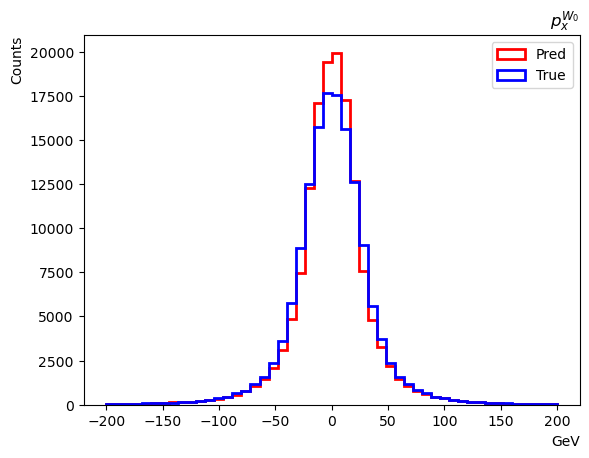

W0 px RMSE: 13.498510308310761


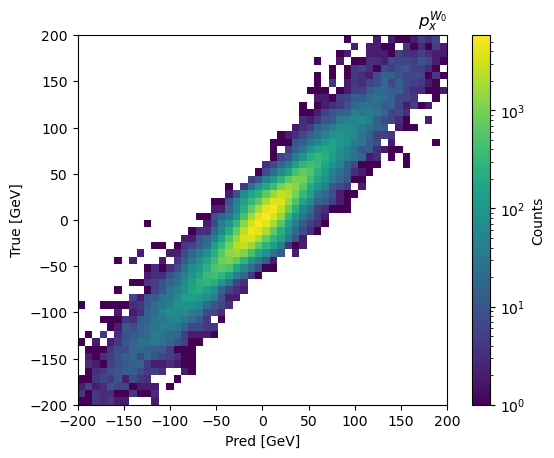

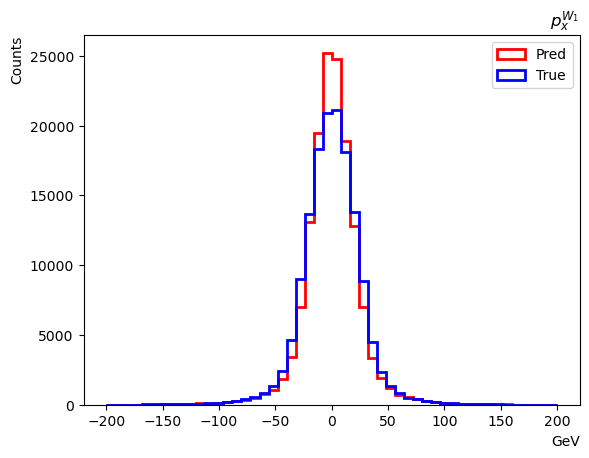

W1 px RMSE: 13.107081005851022


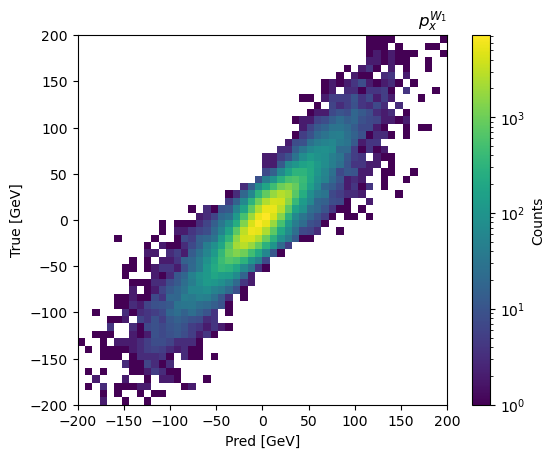

In [ ]:
bins = np.linspace(-200, 200, 51)
plot_1d_hist(pred_lep_pos_px, true_lep_pos_px, bins_edges=bins, name=r"$p_x^{\ell_0}$")
print("W0 px RMSE:", rmse(pred_lep_pos_px, true_lep_pos_px))
plot_2d_hist(pred_lep_pos_px, true_lep_pos_px, name=r"$p_x^{\ell_0}$", bins_edges=bins, log=True)
plot_1d_hist(pred_lep_neg_px, true_lep_neg_px, bins_edges=bins, name=r"$p_x^{\ell_1}$")
print("W1 px RMSE:", rmse(pred_lep_neg_px, true_lep_neg_px))
plot_2d_hist(pred_lep_neg_px, true_lep_neg_px, name=r"$p_x^{\ell_1}$", bins_edges=bins, log=True)

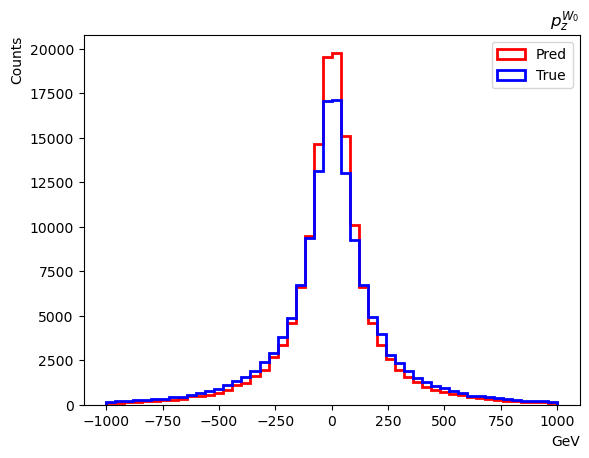

W0 pz RMSE: 124.07799566058989


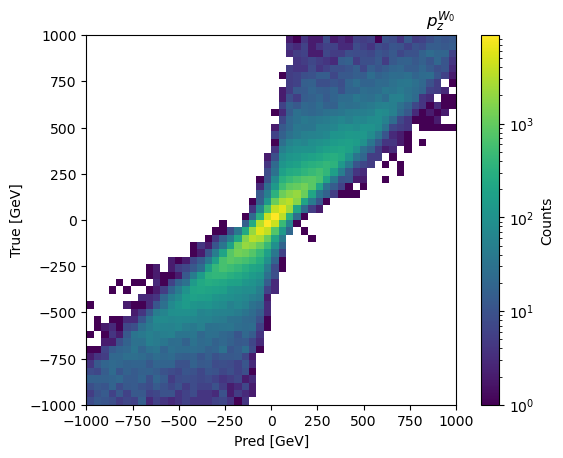

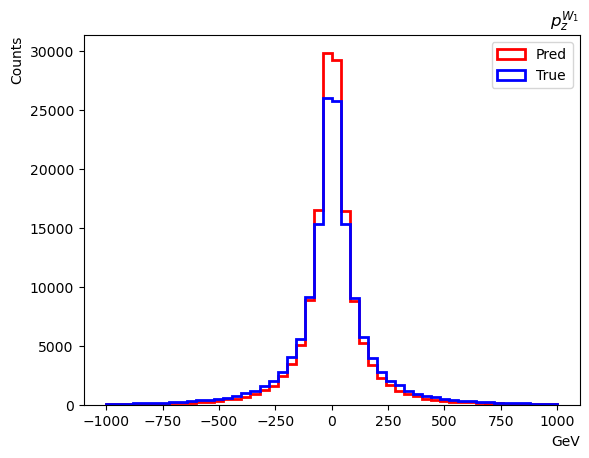

W1 pz RMSE: 94.60272632677966


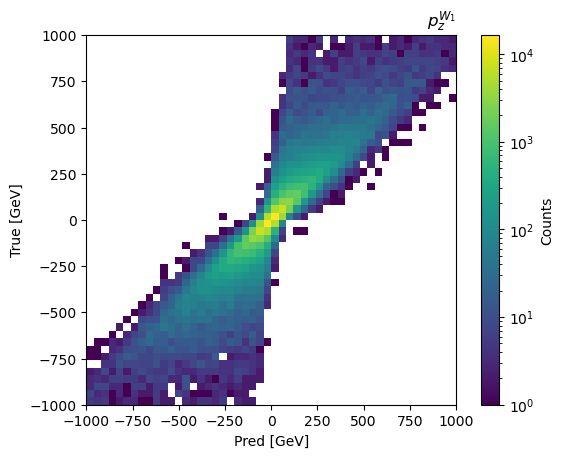

In [ ]:
bins = np.linspace(-1000, 1000, 51)
plot_1d_hist(pred_lep_pos_pz, true_lep_pos_pz, bins_edges=bins, name=r"$p_z^{\ell_0}$")
print("W0 pz RMSE:", rmse(pred_lep_pos_pz, true_lep_pos_pz))
plot_2d_hist(pred_lep_pos_pz, true_lep_pos_pz, name=r"$p_z^{\ell_0}$", bins_edges=bins, log=True)
plot_1d_hist(pred_lep_neg_pz, true_lep_neg_pz, bins_edges=bins, name=r"$p_z^{\ell_1}$")
print("W1 pz RMSE:", rmse(pred_lep_neg_pz, true_lep_neg_pz))
plot_2d_hist(pred_lep_neg_pz, true_lep_neg_pz, name=r"$p_z^{\ell_1}$", bins_edges=bins, log=True)

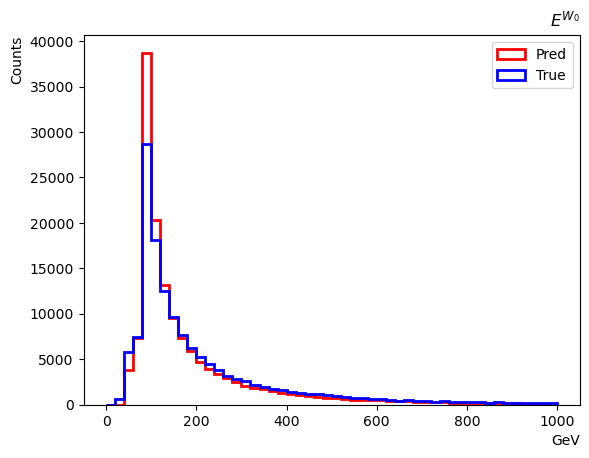

W0 energy RMSE: 120.17086390845581


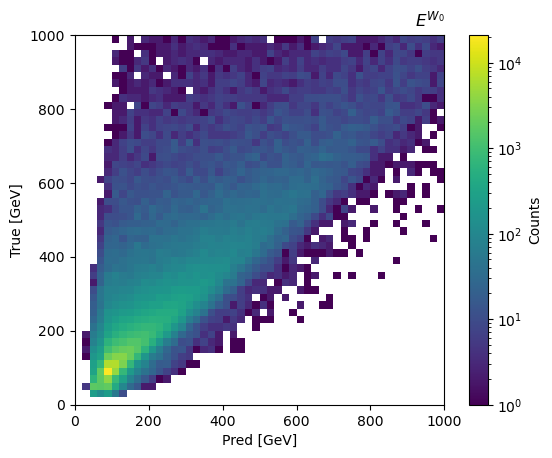

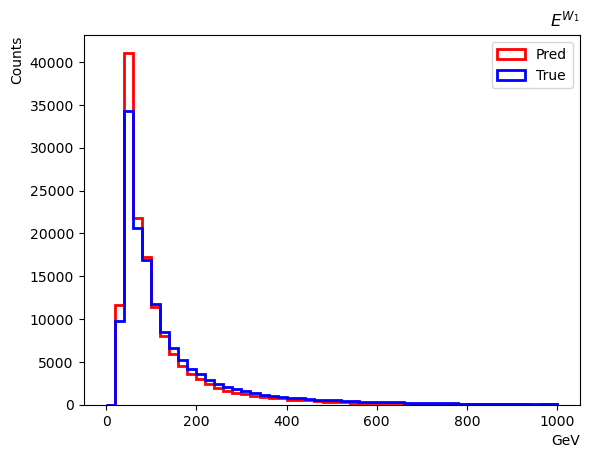

W1 energy RMSE: 92.66281920167629


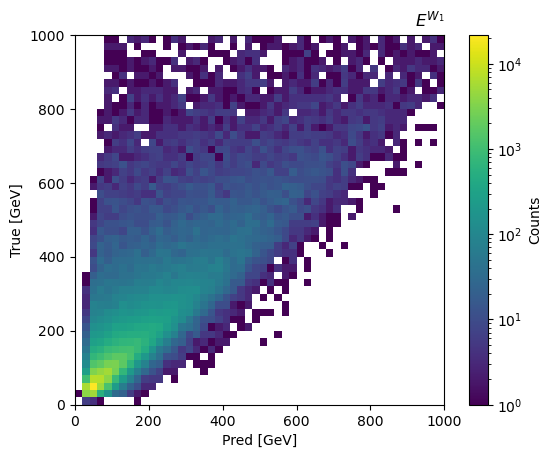

In [ ]:
bins = np.linspace(0, 1000, 51)
plot_1d_hist(pred_lep_pos_energy, true_lep_pos_energy, bins_edges=bins, name=r"$E^{\ell_0}$")
print("W0 energy RMSE:", rmse(pred_lep_pos_energy, true_lep_pos_energy))
plot_2d_hist(pred_lep_pos_energy, true_lep_pos_energy, name=r"$E^{\ell_0}$", bins_edges=bins, log=True)
plot_1d_hist(pred_lep_neg_energy, true_lep_neg_energy, bins_edges=bins, name=r"$E^{\ell_1}$")
print("W1 energy RMSE:", rmse(pred_lep_neg_energy, true_lep_neg_energy))
plot_2d_hist(pred_lep_neg_energy, true_lep_neg_energy, name=r"$E^{\ell_1}$", bins_edges=bins, log=True)

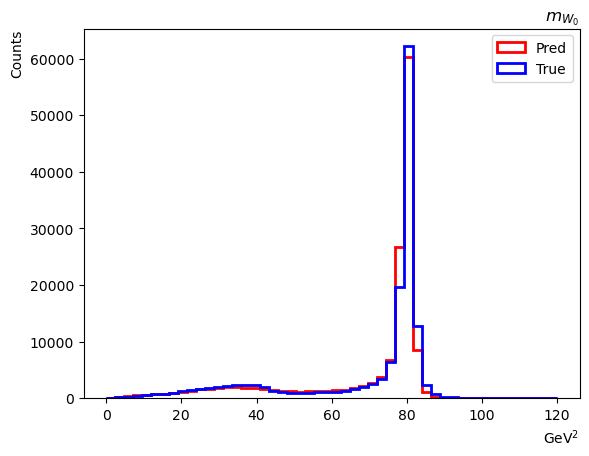

W0 mass RMSE: 18.260914716082628


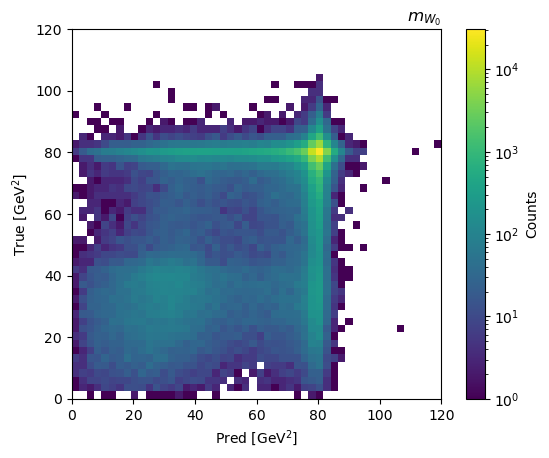

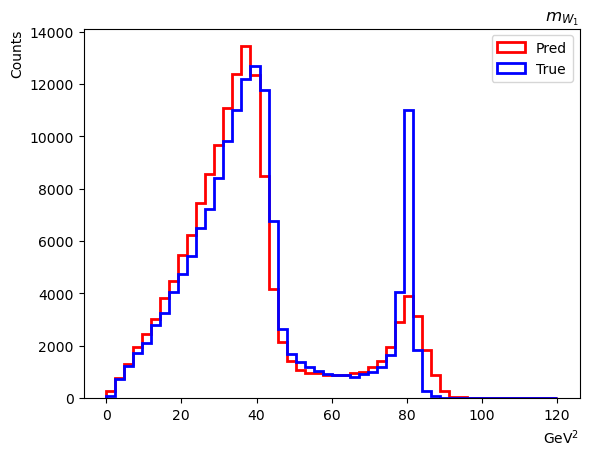

W1 mass RMSE: 18.225756131661424


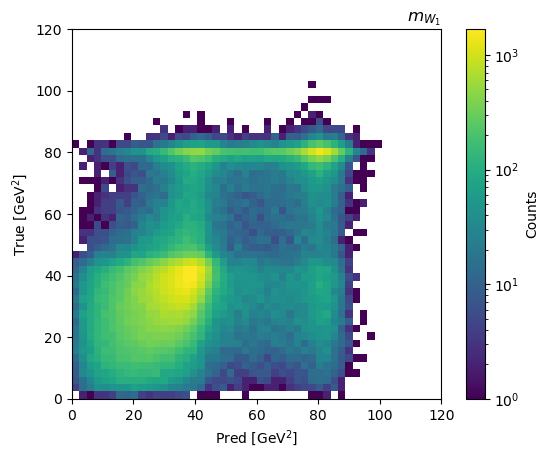

In [ ]:
bins = np.linspace(0, 120, 51)
plot_1d_hist(pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"$m_{W_0}$", unit="GeV")
print("W0 mass RMSE:", rmse(pred_w0_mass, true_w0_mass))
plot_2d_hist(pred_w0_mass, true_w0_mass, name=r"$m_{W_0}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"$m_{W_1}$", unit="GeV")
print("W1 mass RMSE:", rmse(pred_w1_mass, true_w1_mass))
plot_2d_hist(pred_w1_mass, true_w1_mass, name=r"$m_{W_1}$", bins_edges=bins, log=True, unit="GeV")

In [ ]:
def pt(px, py):
    return np.sqrt(np.square(px) + np.square(py))


def eta(px, py, pz):
    pt = np.sqrt(np.square(px) + np.square(py))
    return np.arcsinh(np.divide(pz, pt))

def theta(px, py, pz):
    pt = np.sqrt(np.square(px) + np.square(py))
    return np.arctan2(pt, pz)

def phi(px, py):
    return np.arctan2(py, px)

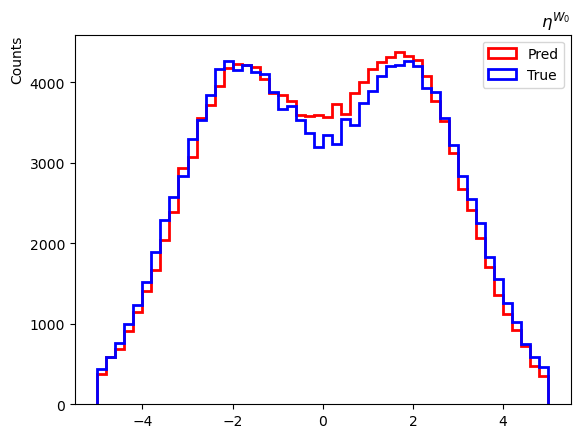

W0 eta RMSE: 0.8337160465150815


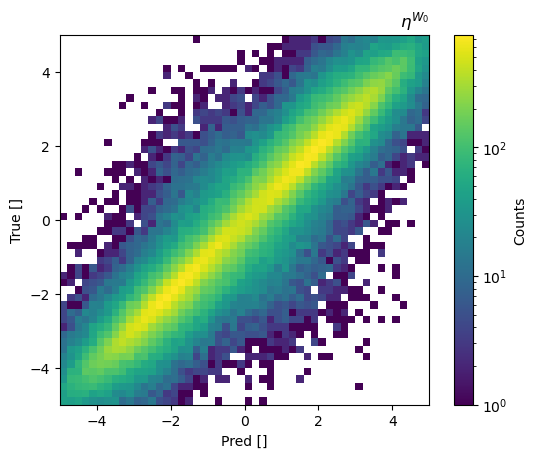

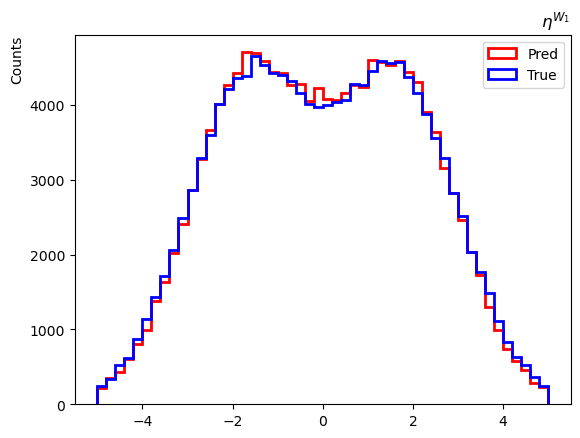

W1 eta RMSE: 0.8442474485118078


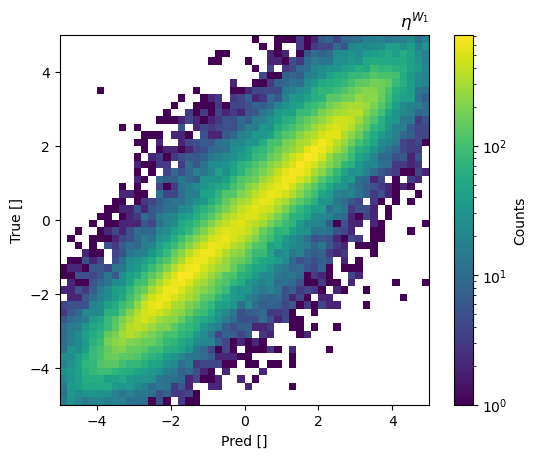

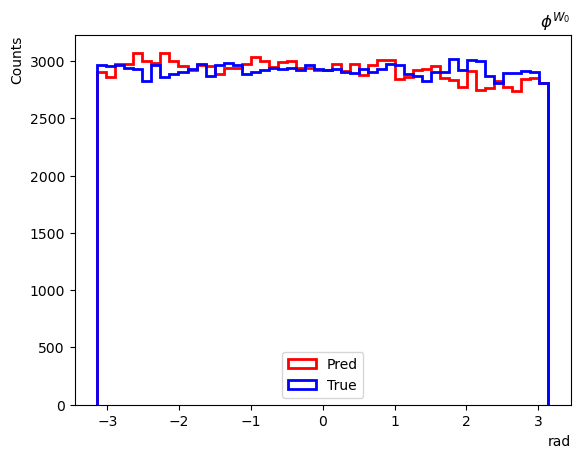

W0 phi RMSE: 1.5624854426332557


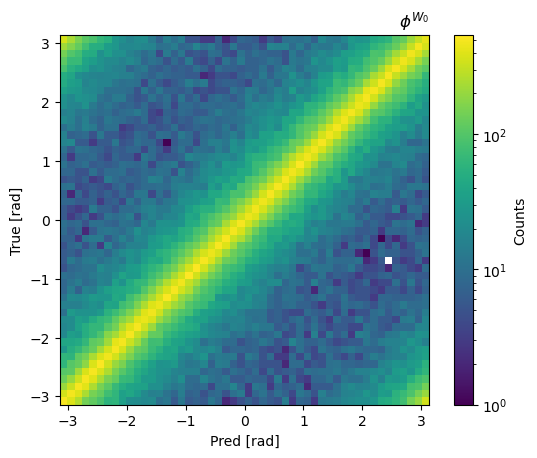

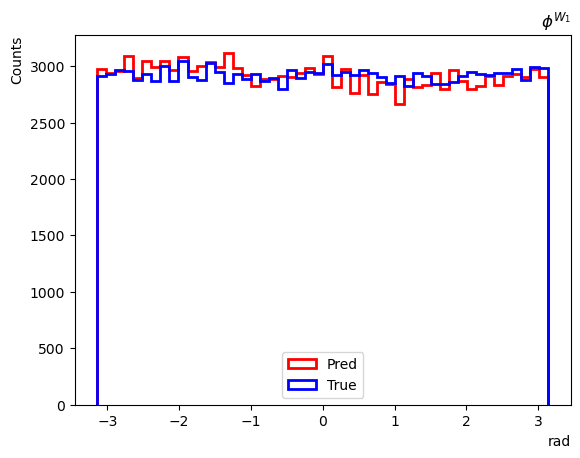

W1 phi RMSE: 1.6798940759245218


In [ ]:
pred_lep_pos_eta = eta(pred_lep_pos_px, pred_lep_pos_py, pred_lep_pos_pz)
true_lep_pos_eta = eta(true_lep_pos_px, true_lep_pos_py, true_lep_pos_pz)
pred_lep_neg_eta = eta(pred_lep_neg_px, pred_lep_neg_py, pred_lep_neg_pz)
true_lep_neg_eta = eta(true_lep_neg_px, true_lep_neg_py, true_lep_neg_pz)

pred_lep_pos_theta = theta(pred_lep_pos_px, pred_lep_pos_py, pred_lep_pos_pz)
true_lep_pos_theta = theta(true_lep_pos_px, true_lep_pos_py, true_lep_pos_pz)
pred_lep_neg_theta = theta(pred_lep_neg_px,	pred_lep_neg_py, pred_lep_neg_pz)
true_lep_neg_theta = theta(true_lep_neg_px, true_lep_neg_py, true_lep_neg_pz)

pred_lep_pos_phi = phi(pred_lep_pos_px, pred_lep_pos_py)
true_lep_pos_phi = phi(true_lep_pos_px, true_lep_pos_py)
pred_lep_neg_phi = phi(pred_lep_neg_px, pred_lep_neg_py)
true_lep_neg_phi = phi(true_lep_neg_px, true_lep_neg_py)

In [ ]:
bins = np.linspace(-5, 5, 51)
plot_1d_hist(pred_lep_pos_eta, true_lep_pos_eta, bins_edges=bins, name=r"$\eta_{\ell_0}$", unit="")
print("l+ eta RMSE:", rmse(pred_lep_pos_eta, true_lep_pos_eta))
plot_2d_hist(pred_lep_pos_eta, true_lep_pos_eta, name=r"$\eta_{\ell_0}$", bins_edges=bins, log=True, unit="")
plot_1d_hist(pred_lep_neg_eta, true_lep_neg_eta, bins_edges=bins, name=r"$\eta_{\ell_1}$", unit="")
print("l- eta RMSE:", rmse(pred_lep_neg_eta, true_lep_neg_eta))
plot_2d_hist(pred_lep_neg_eta, true_lep_neg_eta, name=r"$\eta_{\ell_1}$", bins_edges=bins, log=True, unit="")
plot_1d_hist(pred_lep_pos_phi, true_lep_pos_phi, bins_edges=np.linspace(-np.pi, np.pi, 51), name=r"$\phi_{\ell_0}$", unit="rad")
print("l+ phi RMSE:", rmse(pred_lep_pos_phi, true_lep_pos_phi))
plot_2d_hist(pred_lep_pos_phi, true_lep_pos_phi, name=r"$\phi_{\ell_0}$", bins_edges=np.linspace(-np.pi, np.pi, 51), log=True, unit="rad")
plot_1d_hist(pred_lep_neg_phi, true_lep_neg_phi, bins_edges=np.linspace(-np.pi, np.pi, 51), name=r"$\phi_{\ell_1}$", unit="rad")
print("l- phi RMSE:", rmse(pred_lep_neg_phi, true_lep_neg_phi))
plot_2d_hist(pred_lep_neg_phi, true_lep_neg_phi, name=r"$\phi_{\ell_1}$", bins_edges=np.linspace(-np.pi, np.pi, 51), log=True, unit="rad")
plot_1d_hist(pred_lep_pos_theta, true_lep_pos_theta, bins_edges=bins, name=r"$\theta_{\ell_0}$", unit="rad")
print("l+ theta RMSE:", rmse(pred_lep_pos_theta, true_lep_pos_theta))
plot_2d_hist(pred_lep_pos_theta, true_lep_pos_theta, name=r"$\theta_{\ell_0}$", bins_edges=bins, log=True, unit="rad")
plot_1d_hist(pred_lep_neg_theta, true_lep_neg_theta, bins_edges=bins, name=r"$\theta_{\ell_1}$", unit="rad")
print("l- theta RMSE:", rmse(pred_lep_neg_theta, true_lep_neg_theta))
plot_2d_hist(pred_lep_neg_theta, true_lep_neg_theta, name=r"$\theta_{\ell_1}$", bins_edges=bins, log=True, unit="rad")

Found log directories: ['./hww_pcres_regressor/logs/version_0']


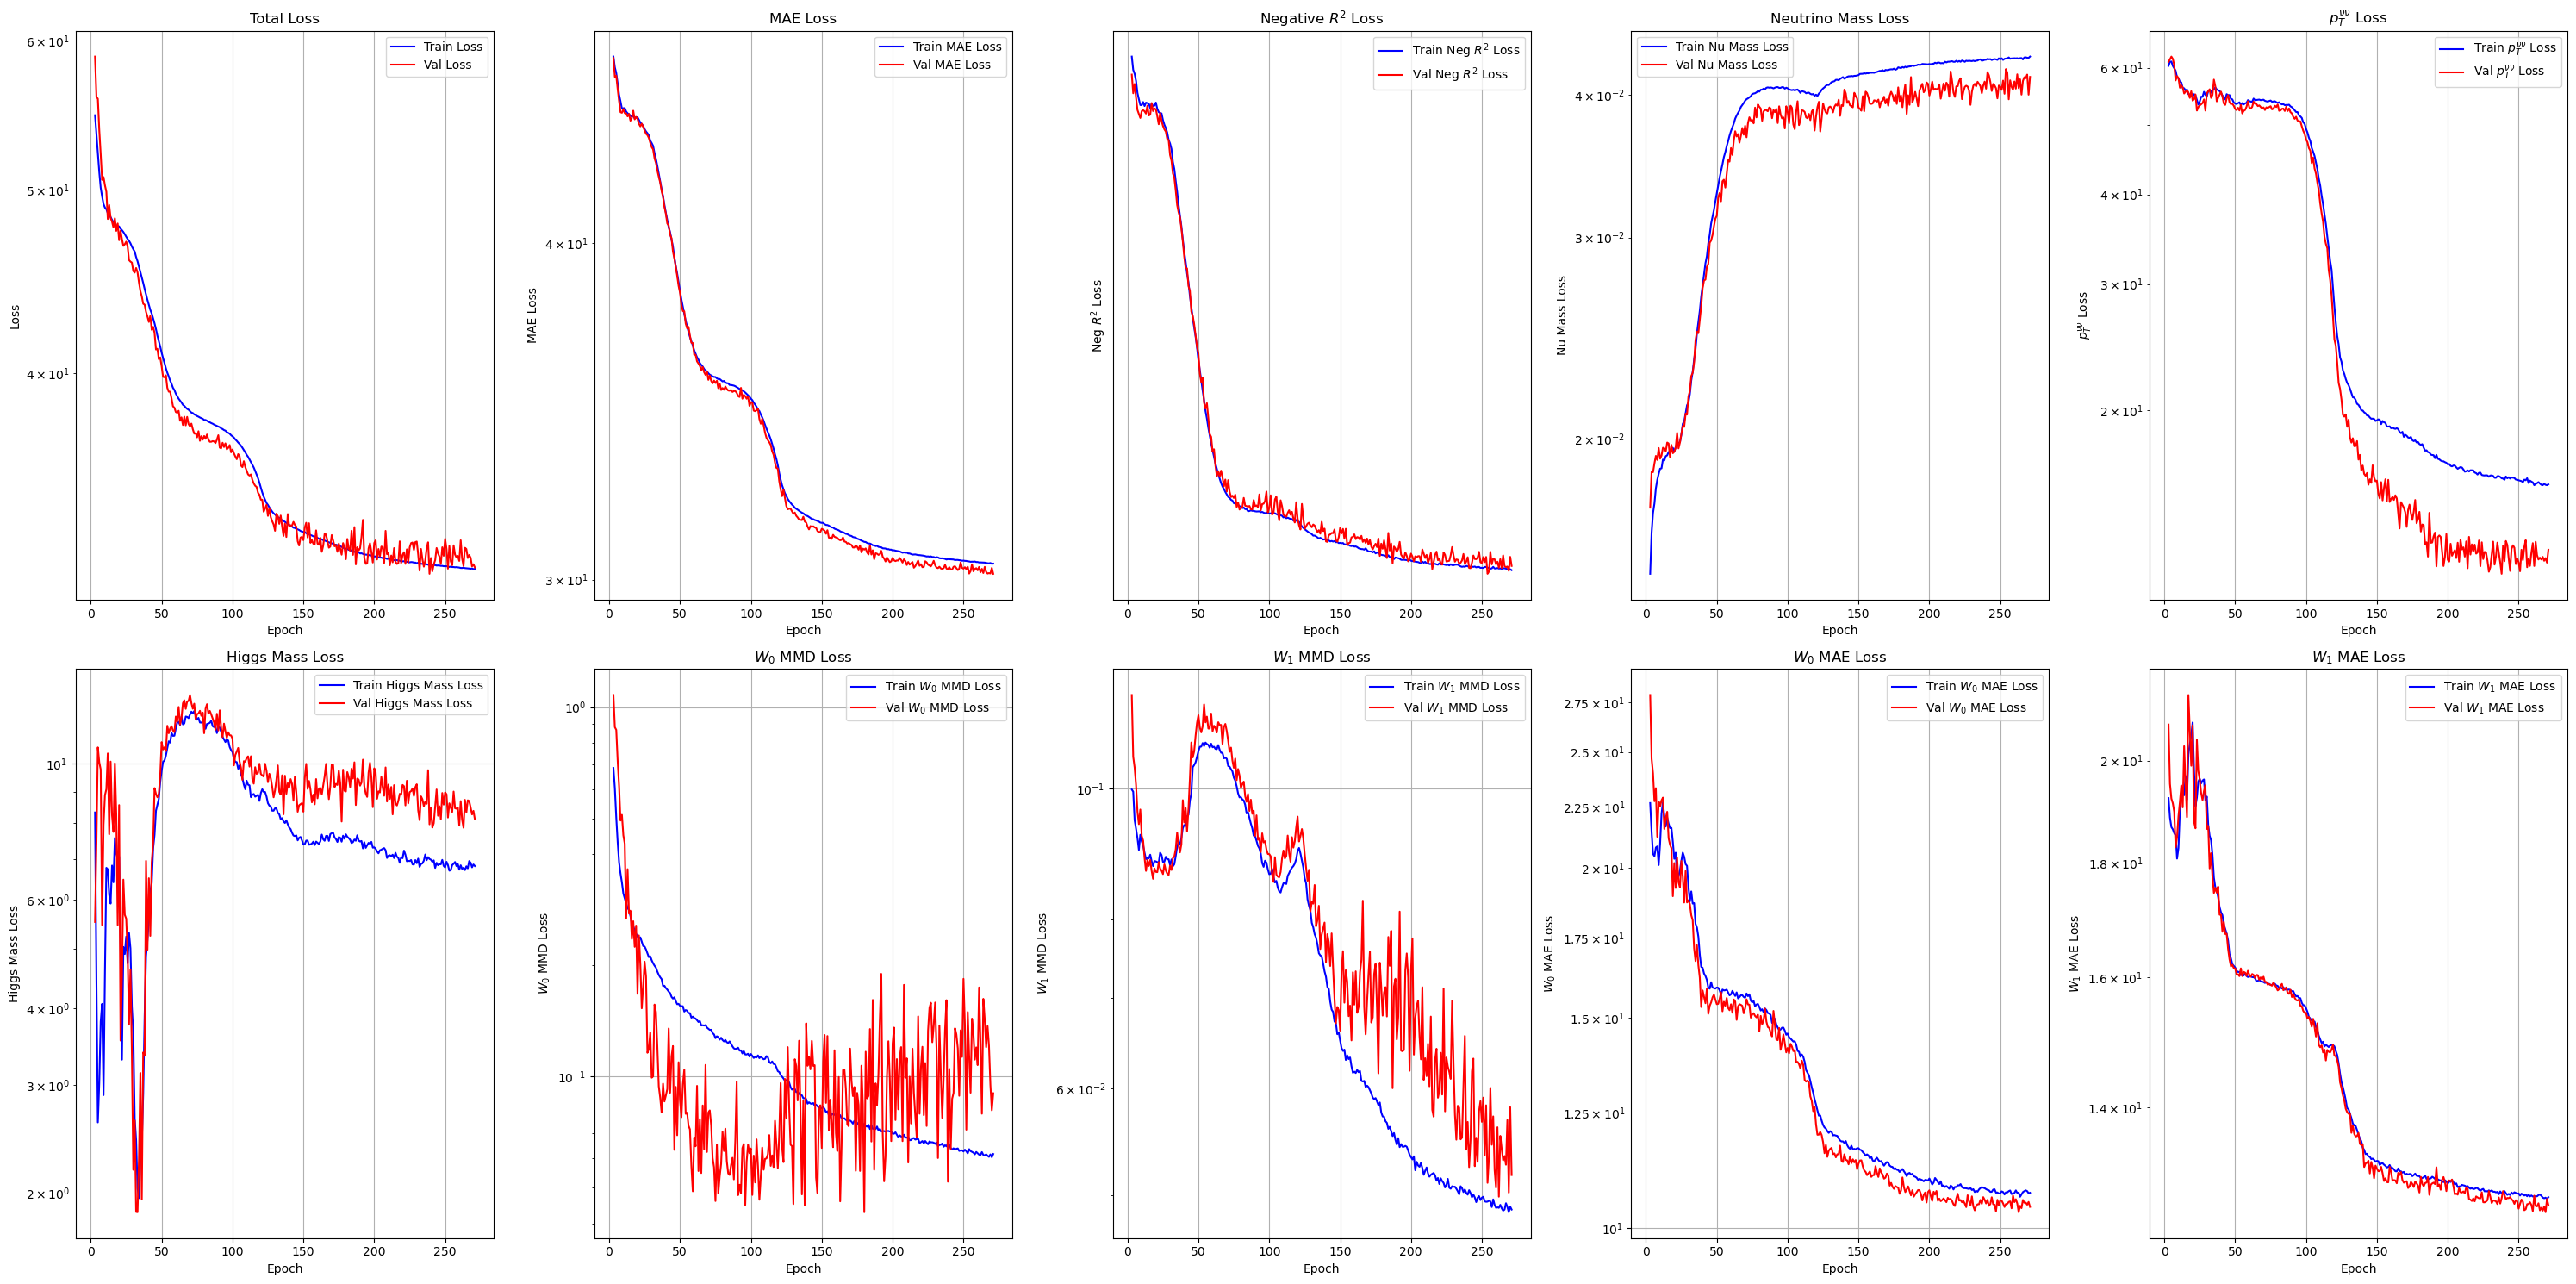


Final Training Losses (Epoch 271):
  Total Loss: 31.517033
  MAE Loss: 30.412678
  Negative $R^2$ Loss: -0.840018
  Neutrino Mass Loss: 0.043211
  $p^{\nu\nu}_T$ Loss: 15.789965
  Higgs Mass Loss: 6.813818
  $W_0$ MMD Loss: 0.061626
  $W_1$ MMD Loss: 0.048807
  $W_0$ MAE Loss: 10.709024
  $W_1$ MAE Loss: 12.766517

Final Validation Losses:
  Total Loss: 31.567244
  MAE Loss: 30.149355
  Negative $R^2$ Loss: -0.838768
  Neutrino Mass Loss: 0.041478
  $p^{\nu\nu}_T$ Loss: 12.806871
  Higgs Mass Loss: 8.116931
  $W_0$ MMD Loss: 0.090029
  $W_1$ MMD Loss: 0.051760
  $W_0$ MAE Loss: 10.422220
  $W_1$ MAE Loss: 12.663529


In [ ]:
log_dirs = glob.glob("./hww_pcres_regressor/logs/*")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 15))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("mae_loss", "val_mae_loss", "MAE Loss", "MAE Loss"),
                # ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                # ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                # ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                # ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W_0$ MMD Loss", "$W_0$ MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W_1$ MMD Loss", "$W_1$ MMD Loss"),
                # ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W_0$ MAE Loss", "$W_0$ MAE Loss"),
                # ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W_1$ MAE Loss", "$W_1$ MAE Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[3:]
            epochs_val = df_clean_val["epoch"].iloc[3:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[3:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[3:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"\nFinal Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("\nFinal Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")